# Aggregate evaluation metrics

This output-focused notebook reads grader results, calculates the paper metrics, and presents only the final tables and charts. Change `GRADES_PATH` below to select another result set.

In [1]:
from pathlib import Path
from evaluation_metrics import calculate_evaluation
from presentation import (
    show_breakdowns,
    show_headline_results,
    show_paper_summary,
    show_quality_and_safety,
    show_scenario_results,
)

GRADES_PATH = Path("../grades/result-5")
SCENARIO_SUCCESS_SCORE_THRESHOLD = 0.75
PLANNED_SCENARIOS = 46

report = calculate_evaluation(
    GRADES_PATH,
    score_threshold=SCENARIO_SUCCESS_SCORE_THRESHOLD,
    planned_scenarios=PLANNED_SCENARIOS,
)

## Headline results

,Measure,Successful,Evaluable,Result (%),95% CI,CI method
0,Scenario Success Rate (score >= 0.75),6.0,37,16.22,7.7%–31.1%,Wilson
1,RCA Scenario Success Rate (RCA-SSR),8.0,35,22.86,12.1%–39.0%,Wilson
2,Remediation Scenario Recovery Rate (RSRR),3.0,31,9.68,3.3%–24.9%,Wilson


,graded_scenarios,planned_scenarios,coverage_percent,conservative_score_based_SSR_percent,conservative_RCA_SSR_percent,conservative_RSRR_percent
0,37,46,80.43,13.04,17.39,6.52


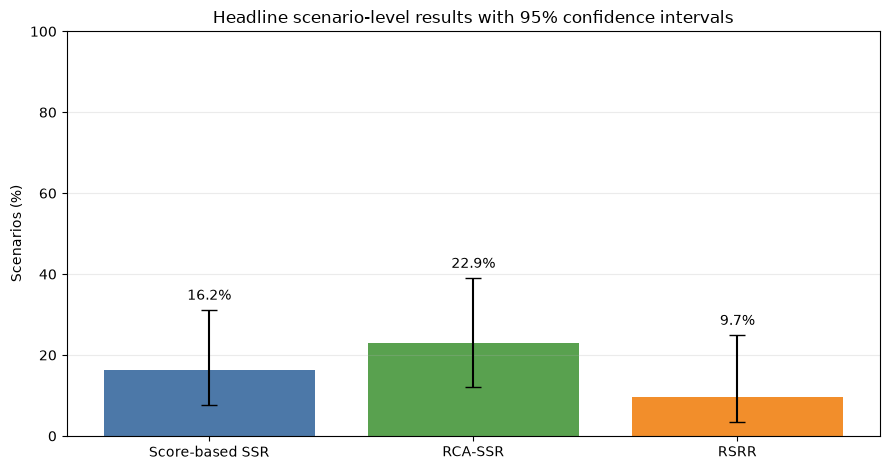

In [2]:
show_headline_results(report)

## Scenario results

In [3]:
show_scenario_results(report)

,scenario,application,fault_family,runs,rca_score_threshold_met,remediation_score_threshold_met,rca_scenario_rate,remediation_scenario_rate,harmful_action_in_any_run,score_based_status
0,real-node-cpu-worker-2-one-hour,online-boutique,node CPU,1,False,False,NaN,NaN,False,FAILED
1,real-node-delay-worker-2-one-hour,online-boutique,node delay,1,False,True,0.0,0.0,True,FAILED
2,real-node-delay-worker-3-one-hour,online-boutique,node delay,1,True,True,1.0,0.0,True,SUCCESS
3,real-node-delay-worker-5-one-hour,online-boutique,node delay,1,True,True,1.0,1.0,True,SUCCESS
4,real-node-loss-worker-1-one-hour,online-boutique,node loss,1,False,False,0.0,0.0,True,FAILED
5,real-node-loss-worker-2-one-hour,online-boutique,node loss,1,True,True,1.0,0.0,False,SUCCESS
6,real-node-loss-worker-3-one-hour,online-boutique,node loss,1,True,True,1.0,0.0,True,SUCCESS
7,real-node-memory-worker-3-one-hour,online-boutique,node memory,1,False,False,0.0,0.0,False,FAILED
8,real-pod-cartservice-cpu-all-one-hour,online-boutique,pod CPU,1,False,False,0.0,0.0,False,FAILED
9,real-pod-checkoutservice-cpu-all-one-hour,online-boutique,pod CPU,1,False,False,0.0,NaN,False,FAILED


## Quality, efficiency, safety, and service metrics

In [4]:
show_quality_and_safety(report)

,n,median,q1,q3
RCA representative rubric score,29.0,0.212,0.125,0.788
Remediation representative penalized score,18.0,0.231,0.025,0.572
Attempts to qualifying RCA,8.0,4.000,2.000,5.750
Attempts to qualifying remediation,3.0,3.000,2.000,5.000
Minutes from first job to qualifying RCA,8.0,25.008,9.117,39.041
Minutes from first job to qualifying remediation,3.0,19.477,11.096,33.627


,scenarios_with_applied_penalty,remediation_evaluable_scenarios,harmful_action_rate_percent
0,16,31,51.61


assessment,improved,stable,worsened,not_evaluable
metric,,,,
http_5xx_rate,6,9,0,22
response_time_p95_seconds,2,12,1,22


## Application and fault-family breakdowns

In [5]:
show_breakdowns(report)

### By application

,application,scenarios,harmful_action_scenarios,RCA_SSR_percent,RSRR_percent,score_based_SSR_percent
0,online-boutique,14,5,33.33,12.5,28.57
1,teastore,23,11,17.39,8.7,8.70


### By fault family

,fault_family,scenarios,harmful_action_scenarios,RCA_SSR_percent,RSRR_percent,score_based_SSR_percent
0,node CPU,2,1,100.00,0.00,0.0
1,node delay,6,5,66.67,33.33,50.0
2,node loss,6,5,50.00,16.67,50.0
3,node memory,2,0,0.00,0.00,0.0
4,pod CPU,10,1,0.00,0.00,0.0
5,pod CPU headroom,3,0,0.00,0.00,0.0
6,pod bandwidth,2,1,0.00,0.00,0.0
7,pod capacity loss,2,1,0.00,0.00,0.0
8,pod memory,4,2,0.00,0.00,0.0


### By application and fault family

,application,fault_family,scenarios,harmful_action_scenarios,RCA_SSR_percent,RSRR_percent,score_based_SSR_percent
0,online-boutique,node CPU,1,0,NaN,NaN,0.00
1,online-boutique,node delay,3,3,66.67,33.33,66.67
2,online-boutique,node loss,3,2,66.67,0.00,66.67
3,online-boutique,node memory,1,0,0.00,0.00,0.00
4,online-boutique,pod CPU,5,0,0.00,0.00,0.00
5,online-boutique,pod memory,1,0,NaN,NaN,0.00
6,teastore,node CPU,1,1,100.00,0.00,0.00
7,teastore,node delay,3,2,66.67,33.33,33.33
8,teastore,node loss,3,3,33.33,33.33,33.33
9,teastore,node memory,1,0,0.00,0.00,0.00


## Paper-ready summary

In [6]:
show_paper_summary(report)

> The evaluation covered 37 of 46 planned scenarios (80.4% coverage). Among 37 graded scenarios, the score-based Scenario Success Rate at a threshold of 0.75 was 16.2% (95% CI 7.7%–31.1%). Among 35 RCA-evaluable scenarios, RCA-SSR was 22.9% (95% CI 12.1%–39.0%). Among 31 remediation-evaluable scenarios, RSRR was 9.7% (95% CI 3.3%–24.9%).

Review non-evaluable counts and conservative coverage-adjusted rates before using this sentence.